In [10]:
from PIL import Image
import numpy as np

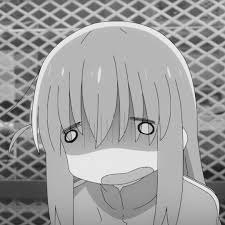

In [11]:
img = Image.open("boccher.jpg").convert("L") # .convert("L") grayscale
img

In [12]:
arr = np.array(img, dtype=np.float64) # dtype=np.float64 precise error propagation 

In [14]:
arr.shape

(225, 225)

In [13]:
# Floyd - Steinberg

# for each y from top to bottom do
#     for each x from left to right do
#         oldpixel := pixels[x][y]
#         newpixel := find_closest_palette_color(oldpixel)
#         pixels[x][y] := newpixel
#         quant_error := oldpixel - newpixel
#         pixels[x + 1][y    ] := pixels[x + 1][y    ] + quant_error × 7 / 16
#         pixels[x - 1][y + 1] := pixels[x - 1][y + 1] + quant_error × 3 / 16
#         pixels[x    ][y + 1] := pixels[x    ][y + 1] + quant_error × 5 / 16
#         pixels[x + 1][y + 1] := pixels[x + 1][y + 1] + quant_error × 1 / 16

In [ ]:
# Floyd - Steinberg 1-bit BW
for y in range(len(arr)-1):
    for x in range(len(arr[0])-1):
        old = arr[x][y]
        new = 255 if old > 127 else 0
        arr[x][y] = new
        err = old - new

        arr[x+1][y] += err * 7/16
        arr[x-1][y+1] += err * 3/16
        arr[x][y+1] += err * 5/16
        arr[x+1][y+1] += err * 1/16

In [16]:
res = np.clip(arr, 0, 255).astype(np.uint8) # pixel value constraints

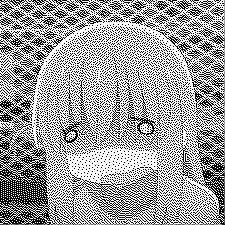

In [17]:
Image.fromarray(res)

In [18]:
# Floyd - Steinberg 3-bit RGB

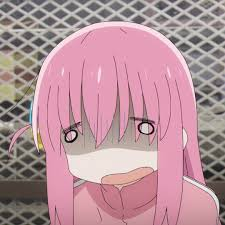

In [19]:
img = Image.open("./boccher.jpg")
img

In [20]:
arr = np.array(img, dtype=np.float64)

In [21]:
arr.shape

(225, 225, 3)

In [22]:
for c in range(3):
    for y in range(len(arr)-1):
        for x in range(len(arr[0])-1):
            old = arr[x][y][c]
            new = 255 if arr[x][y][c] > 127 else 0
            arr[x][y][c] = new
            err = old - new

            arr[x+1][y][c] += err * 7/16
            arr[x-1][y+1][c] += err * 3/16
            arr[x][y+1][c] += err * 5/16
            arr[x+1][y+1][c] += err * 1/16

In [24]:
res = np.clip(arr, 0, 255).astype(np.uint8)

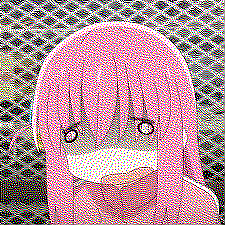

In [25]:
Image.fromarray(res)

In [26]:
# Atkinson

In [29]:
img = Image.open("./boccher.jpg").convert("L")

In [30]:
arr = np.array(img, dtype=np.float64)